# MASTERCLASS — RETO - 

## Autor: Josef  Rodríguez 

# Clase 10 — Clasificación con Dataset Desbalanceado (A/B Split + WOE/IV + PSI + KS/Lift/Gains + Tuning)

**Dataset:** Depósito a Plazo (Target: `FLG_VTA`)  
**Objetivo:** Construir un pipeline *industrial* para clasificación binaria con **desbalance extremo**, separando un set **B** que simula **producción**.

---

## ¿Qué aprenderás en este notebook?

1. **Separación A/B** (A = desarrollo, B = validación estilo producción) y **verificación de homogeneidad**.
2. **PSI (Population Stability Index)** para chequear estabilidad/distribución A vs B.
3. Limpieza de categóricas (**Top-5 + 'otros' + 'missing'**) para robustez en producción.
4. **WOE (Weight of Evidence)** para encoding categórico (típico de banca/credit scoring).
5. **IV (Information Value)** para medir poder predictivo de variables.
6. **Feature Engineering** básico (ejemplos concretos).
7. Manejo de desbalance (**class_weight**, **SMOTE**).
8. Modelos + **tuning** (GridSearchCV) y evaluación con **ROC-AUC**, **PR**, **KS**, **Lift** y **Gains**.
9. Evaluación final en **B** (producción simulada).

> Nota: Todas las transformaciones se calculan **solo en Train** y se aplican a Test/B para evitar *data leakage*.

In [1]:

# ==============================
# 0) Configuración
# ==============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
TARGET = "FLG_VTA"
ID_COL = "ID_SEC"

## 1) Carga del dataset

**Por qué:** antes de modelar debemos validar estructura, tipos y nulos. Esto reduce errores y detecta fugas (leakage).

In [2]:

# ==========================================
# 2) Carga de datos (GitHub raw) + fallback local
# ==========================================
GITHUB_RAW = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/Dataset_DepPlazo.csv"
LOCAL_PATH = "data/Dataset_DepPlazo.csv"  # si clonan el repo y ejecutan desde la raíz

try:
    df = pd.read_csv(GITHUB_RAW)
    print("Dataset cargado desde GitHub ")
except Exception as e:
    print("No se pudo cargar desde GitHub. Intentando local...")
    df = pd.read_csv(LOCAL_PATH)
    print("Dataset cargado desde ruta local ")

print("Shape:", df.shape)
display(df.head())

No se pudo cargar desde GitHub. Intentando local...
Dataset cargado desde ruta local 
Shape: (169059, 12)


,ID_SEC,FLGSEXO,TIPESTCIVIL,TIPNIVELEDUCACIONAL,TIPSITUACIONLABORAL,EDAD,DEPARTAMENTO,INGRESO_ESTIMADO,NIVEL_SOCIECON,SEGMENTO_DIGITAL,SEGMENTO_BANCO,FLG_VTA
0,169124,M,SOL,NDI,DEP,33,MOQUEGUA,8087.0600,D,DIGITAL ALTO,SEG_4,0
1,59736,M,CAS,MAE,DEP,44,LIMA,19000.0000,B,DIGITAL ALTO,SEG_5,0
2,60798,M,CAS,TIT,IND,67,LIMA,6684.5875,B,DIGITAL ALTO,SEG_10,0
3,18480,F,CAS,NDI,DEP,58,LIMA,37019.0750,A,DIGITAL ALTO,SEG_7,0
4,61461,F,CAS,TEC,NDI,58,LIMA,3070.2900,D,DIGITAL ALTO,SEG_1,0


## 2) Análisis del target (desbalance)

**Por qué:** en desbalance extremo, `accuracy` es engañosa. Necesitamos métricas como **ROC-AUC, PR-AUC, Recall, F1** y herramientas como **KS / Lift / Gains**.

Conteo target:
 FLG_VTA
0    168678
1       381
Name: count, dtype: int64

Proporción target:
 FLG_VTA
0    0.997746
1    0.002254
Name: proportion, dtype: float64

Naive accuracy (si predices TODO 0): 0.9977


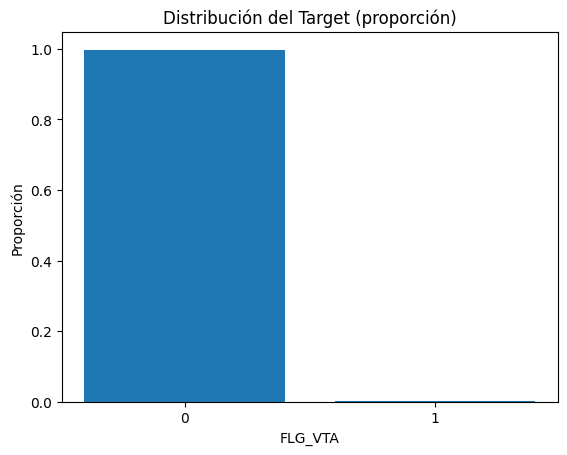

In [3]:

vc = df[TARGET].value_counts()
vcp = df[TARGET].value_counts(normalize=True)

print("Conteo target:\n", vc)
print("\nProporción target:\n", vcp)

# Baseline naive: predecir siempre 0
acc_naive = (df[TARGET] == 0).mean()
print(f"\nNaive accuracy (si predices TODO 0): {acc_naive:.4f}")

plt.figure()
plt.bar(vcp.index.astype(str), vcp.values)
plt.title("Distribución del Target (proporción)")
plt.xlabel(TARGET); plt.ylabel("Proporción")
plt.show()

## 3) Separación A/B (A = desarrollo, B = producción simulada)

**Por qué:** en industria se separa un set *holdout* que simula datos futuros/producción.  
- **A**: se usa para entrenar, validar, seleccionar features e hiperparámetros.  
- **B**: se usa **solo al final** para estimar performance fuera de muestra (proxy de producción).

> Importante: usamos `stratify` para conservar el porcentaje de la clase minoritaria en ambos grupos.

In [4]:

A, B = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

print("A shape:", A.shape, " | B shape:", B.shape)
print("\nA target proporción:\n", A[TARGET].value_counts(normalize=True))
print("\nB target proporción:\n", B[TARGET].value_counts(normalize=True))

A shape: (135247, 12)  | B shape: (33812, 12)

A target proporción:
 FLG_VTA
0    0.997745
1    0.002255
Name: proportion, dtype: float64

B target proporción:
 FLG_VTA
0    0.997752
1    0.002248
Name: proportion, dtype: float64


## 4) Funciones: PSI (Population Stability Index)

**Qué es:** PSI mide si la distribución de una variable cambió entre dos poblaciones (p.ej. A vs B).  
**Por qué:** si A y B son muy distintos, el modelo entrenado en A puede fallar en B (drift/shift).

**Interpretación típica (banca):**
- PSI < 0.10 → estable
- 0.10–0.25 → cambio moderado (alerta)
- > 0.25 → cambio fuerte (drift)

In [5]:

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def psi_numeric(a: pd.Series, b: pd.Series, bins: int = 10) -> float:
    a = a.dropna()
    b = b.dropna()
    if a.nunique() <= 1 or b.nunique() <= 1:
        return 0.0

    qs = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(a, qs))
    if len(cut_points) <= 2:
        return 0.0

    a_bins = pd.cut(a, bins=cut_points, include_lowest=True)
    b_bins = pd.cut(b, bins=cut_points, include_lowest=True)

    a_dist = a_bins.value_counts(normalize=True).sort_index()
    b_dist = b_bins.value_counts(normalize=True).reindex(a_dist.index, fill_value=0.0)

    p = a_dist.values
    q = b_dist.values

    return float(np.sum((p - q) * np.log(_safe_div(p, q))))

def psi_categorical(a: pd.Series, b: pd.Series, top_n: int = 10) -> float:
    a = a.fillna("missing").astype(str)
    b = b.fillna("missing").astype(str)

    top = a.value_counts().nlargest(top_n).index
    a2 = a.where(a.isin(top), "otros")
    b2 = b.where(b.isin(top), "otros")

    a_dist = a2.value_counts(normalize=True)
    b_dist = b2.value_counts(normalize=True).reindex(a_dist.index, fill_value=0.0)

    p = a_dist.values
    q = b_dist.values
    return float(np.sum((p - q) * np.log(_safe_div(p, q))))

def compute_psi_report(A: pd.DataFrame, B: pd.DataFrame, target: str, id_col: str = None) -> pd.DataFrame:
    cols = [c for c in A.columns if c != target and c != id_col]
    rows = []
    for c in cols:
        if pd.api.types.is_numeric_dtype(A[c]):
            val = psi_numeric(A[c], B[c], bins=10)
            typ = "numeric"
        else:
            val = psi_categorical(A[c], B[c], top_n=10)
            typ = "categorical"
        rows.append((c, typ, val))
    rep = pd.DataFrame(rows, columns=["feature", "type", "psi"]).sort_values("psi", ascending=False)
    return rep

## 5) Validación de homogeneidad A vs B con PSI

**Por qué:** asegura que el holdout B sea comparable a A (no debe haber drift fuerte en variables clave).

,feature,type,psi
6,INGRESO_ESTIMADO,numeric,0.000567
3,TIPSITUACIONLABORAL,categorical,0.000487
5,DEPARTAMENTO,categorical,0.000363
9,SEGMENTO_BANCO,categorical,0.000279
2,TIPNIVELEDUCACIONAL,categorical,0.000246
4,EDAD,numeric,0.000242
0,FLGSEXO,categorical,0.000158
1,TIPESTCIVIL,categorical,0.000076
7,NIVEL_SOCIECON,categorical,0.000054
8,SEGMENTO_DIGITAL,categorical,0.000028


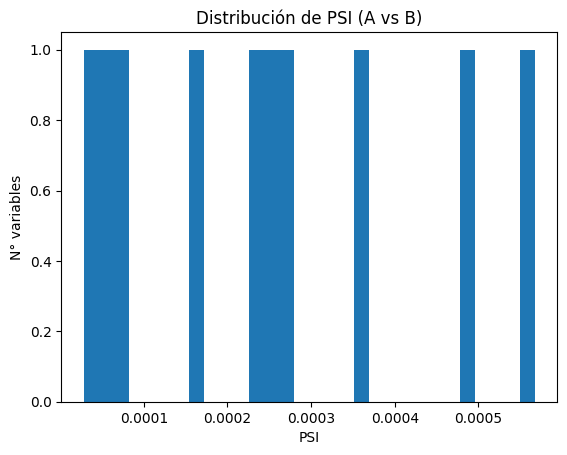

Variables con PSI > 0.25 (drift fuerte):


,feature,type,psi


In [6]:

psi_rep = compute_psi_report(A, B, target=TARGET, id_col=ID_COL)
display(psi_rep.head(20))

plt.figure()
plt.hist(psi_rep["psi"], bins=30)
plt.title("Distribución de PSI (A vs B)")
plt.xlabel("PSI"); plt.ylabel("N° variables")
plt.show()

print("Variables con PSI > 0.25 (drift fuerte):")
display(psi_rep[psi_rep["psi"] > 0.25].head(50))

## 6) Split Train/Test dentro de A (70/30)

**Por qué:** dentro de A hacemos el ciclo de modelado.  
- Train: aprende transformaciones (Top5, WOE, scaling, etc.) y entrena el modelo.
- Test: evalúa performance *out-of-sample* (sin tocar B).

> Siempre **stratify** por el target para conservar la rareza del evento.

In [7]:

train_df, test_df = train_test_split(
    A,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=A[TARGET]
)

print("Train:", train_df.shape, " | Test:", test_df.shape)
print("Train target %:", train_df[TARGET].mean())
print("Test  target %:", test_df[TARGET].mean())

Train: (94672, 12)  | Test: (40575, 12)
Train target %: 0.0022498732465776575
Test  target %: 0.0022674060382008626


## 7) Definición de variables numéricas y categóricas

**Por qué:** cada tipo requiere tratamiento distinto:  
- Numéricas: imputación + scaling + feature engineering
- Categóricas: estandarización de niveles + WOE

> `ID_SEC` se excluye del modelado.

In [8]:

feature_cols = [c for c in train_df.columns if c not in [TARGET, ID_COL]]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

print("Num cols:", num_cols)
print("Cat cols:", cat_cols)

Num cols: ['EDAD', 'INGRESO_ESTIMADO']
Cat cols: ['FLGSEXO', 'TIPESTCIVIL', 'TIPNIVELEDUCACIONAL', 'TIPSITUACIONLABORAL', 'DEPARTAMENTO', 'NIVEL_SOCIECON', 'SEGMENTO_DIGITAL', 'SEGMENTO_BANCO']


## 8) Estandarización de categóricas: Top-5 + 'otros' + 'missing'

**Por qué (producción):**
- En producción aparecen valores raros/nuevos.
- Si no los controlas, el encoding puede fallar o generar NaNs.
- Reducir cardinalidad mejora estabilidad y reduce overfitting.

Regla:
- Tomamos las **5 categorías más frecuentes** en TRAIN.
- Todo lo demás → `'otros'`.
- Nulos → `'missing'`.

In [9]:

def fit_topk_categories(train: pd.DataFrame, cat_cols: list, k: int = 5):
    topk_map = {}
    
    for c in cat_cols:
        s = train[c].astype(str)
        
        # calcular top K ignorando nulos
        topk = s.dropna().value_counts().nlargest(k).index.tolist()
        
        # solo guardamos las top categorías
        topk_map[c] = set(topk)
        
    return topk_map


def apply_topk_categories(df: pd.DataFrame, cat_cols: list, topk_map: dict):
    
    out = df.copy()
    
    for c in cat_cols:
        
        s = out[c].astype(str)
        
        # si es NaN o no está en top categorías → "otros"
        out[c] = s.where(s.isin(topk_map[c]), "otros")
    
    return out

topk_map = fit_topk_categories(train_df, cat_cols, k=5)
train_df2 = apply_topk_categories(train_df, cat_cols, topk_map)
test_df2  = apply_topk_categories(test_df,  cat_cols, topk_map)
B2        = apply_topk_categories(B,       cat_cols, topk_map)

In [10]:
for c in cat_cols:
    print(f"\nVariable: {c}")
    print("Número de categorías:", train_df[c].nunique())

for c in cat_cols:
    print(f"\nVariable: {c}")
    print("Número de categorías:", train_df2[c].nunique())


Variable: FLGSEXO
Número de categorías: 2

Variable: TIPESTCIVIL
Número de categorías: 6

Variable: TIPNIVELEDUCACIONAL
Número de categorías: 13

Variable: TIPSITUACIONLABORAL
Número de categorías: 7

Variable: DEPARTAMENTO
Número de categorías: 25

Variable: NIVEL_SOCIECON
Número de categorías: 4

Variable: SEGMENTO_DIGITAL
Número de categorías: 3

Variable: SEGMENTO_BANCO
Número de categorías: 12

Variable: FLGSEXO
Número de categorías: 2

Variable: TIPESTCIVIL
Número de categorías: 6

Variable: TIPNIVELEDUCACIONAL
Número de categorías: 6

Variable: TIPSITUACIONLABORAL
Número de categorías: 6

Variable: DEPARTAMENTO
Número de categorías: 6

Variable: NIVEL_SOCIECON
Número de categorías: 4

Variable: SEGMENTO_DIGITAL
Número de categorías: 3

Variable: SEGMENTO_BANCO
Número de categorías: 6


## 9) Imputación de nulos (numéricas)

**Por qué:**
- Muchos modelos no aceptan NaNs.
- Mediana es robusta a outliers y suele ser estándar.

Regla:
- Mediana calculada en **train**.
- Aplicada a test y B.

In [11]:

def fit_num_imputer(train: pd.DataFrame, num_cols: list):
    return {c: float(train[c].median()) for c in num_cols}

def apply_num_imputer(df: pd.DataFrame, num_cols: list, medians: dict):
    out = df.copy()
    for c in num_cols:
        out[c] = out[c].fillna(medians[c])
    return out

num_medians = fit_num_imputer(train_df2, num_cols)
train_df3 = apply_num_imputer(train_df2, num_cols, num_medians)
test_df3  = apply_num_imputer(test_df2,  num_cols, num_medians)
B3        = apply_num_imputer(B2,        num_cols, num_medians)

## 10) Feature Engineering (ejemplos)

**Por qué:**
- Algunas relaciones no están explícitas.
- Variables derivadas pueden capturar señales mejores (interacciones/ratios).

Ejemplos:
- `INGRESO_ESTIMADO / EDAD`
- `log(INGRESO_ESTIMADO)`

> Toda FE debe ser determinística y replicable en producción.

In [12]:

def add_feature_engineering(df: pd.DataFrame):
    out = df.copy()
    if "INGRESO_ESTIMADO" in out.columns and "EDAD" in out.columns:
        out["INGRESO_POR_EDAD"] = out["INGRESO_ESTIMADO"] / (out["EDAD"].replace(0, np.nan))
        out["INGRESO_POR_EDAD"] = out["INGRESO_POR_EDAD"].replace([np.inf, -np.inf], np.nan)
        out["INGRESO_POR_EDAD"] = out["INGRESO_POR_EDAD"].fillna(out["INGRESO_POR_EDAD"].median())
    if "INGRESO_ESTIMADO" in out.columns:
        out["LOG_INGRESO"] = np.log1p(out["INGRESO_ESTIMADO"].clip(lower=0))
    return out

train_df4 = add_feature_engineering(train_df3)
test_df4  = add_feature_engineering(test_df3)
B4        = add_feature_engineering(B3)

feature_cols2 = [c for c in train_df4.columns if c not in [TARGET, ID_COL]]
num_cols2 = [c for c in feature_cols2 if pd.api.types.is_numeric_dtype(train_df4[c])]
cat_cols2 = [c for c in feature_cols2 if c not in num_cols2]

print("Num cols (after FE):", num_cols2)
print("Cat cols (after FE):", cat_cols2)

Num cols (after FE): ['EDAD', 'INGRESO_ESTIMADO', 'INGRESO_POR_EDAD', 'LOG_INGRESO']
Cat cols (after FE): ['FLGSEXO', 'TIPESTCIVIL', 'TIPNIVELEDUCACIONAL', 'TIPSITUACIONLABORAL', 'DEPARTAMENTO', 'NIVEL_SOCIECON', 'SEGMENTO_DIGITAL', 'SEGMENTO_BANCO']


## 11) WOE (Weight of Evidence) + IV (Information Value)

### Weight of Evidence (WOE)

El **WOE (Weight of Evidence)** mide la relación entre la proporción de **no eventos** y **eventos** dentro de cada categoría de una variable.

$$
WOE_i = \ln \left( \frac{P(\text{No Evento}_i)}{P(\text{Evento}_i)} \right)
$$

donde:

- $P(\text{No Evento}_i)$ = proporción de observaciones **sin evento** en la categoría $i$  
- $P(\text{Evento}_i)$ = proporción de observaciones **con evento** en la categoría $i$

---

### Information Value (IV)

El **IV (Information Value)** mide el poder predictivo de una variable para separar eventos y no eventos.

$$
IV = \sum_{i=1}^{k} \left( P(\text{No Evento}_i) - P(\text{Evento}_i) \right) \times WOE_i
$$

donde:

- $k$ = número de categorías o bins de la variable

---

### Interpretación del Information Value

| IV | Poder Predictivo |
|----|------------------|
| IV < 0.02 | Variable inútil |
| 0.02 ≤ IV < 0.10 | Poder predictivo débil |
| 0.10 ≤ IV < 0.30 | Poder predictivo medio |
| IV ≥ 0.30 | Poder predictivo fuerte |

---

### Interpretación intuitiva

- Si **WOE > 0**, la categoría tiene mayor proporción de **no eventos**.
- Si **WOE < 0**, la categoría tiene mayor proporción de **eventos**.
- Cuanto mayor sea el **IV**, mayor es la capacidad de la variable para separar ambas clases.

---

### Uso en modelos de Machine Learning

El WOE es muy utilizado en:

- **Credit Scoring**
- **Modelos de riesgo bancario**
- **Modelos de marketing**

Ventajas:

- Convierte variables categóricas en variables numéricas.
- Mantiene la relación con el target.
- Funciona muy bien con **regresión logística**.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def fit_woe_iv(train: pd.DataFrame, col: str, target: str, eps: float = 0.5):
    """
    - eps: smoothing (Laplace) para evitar inf cuando hay 0 eventos/no-eventos.
    Retorna:
      mapper: dict categoría -> woe
      iv: float
      detail: DataFrame con conteos, distribuciones, woe, total, event_rate
    """
    s = train[col].fillna("otros").astype(str)   # si ya estás usando TopK + otros, aquí todo cae en otros
    y = train[target].astype(int)

    tab = pd.crosstab(s, y)
    if 0 not in tab.columns: tab[0] = 0
    if 1 not in tab.columns: tab[1] = 0
    tab = tab[[0, 1]]
    tab.columns = ["no_event", "event"]

    tab_s = tab + eps

    dist_noev = tab_s["no_event"] / tab_s["no_event"].sum()
    dist_ev   = tab_s["event"] / tab_s["event"].sum()

    woe = np.log(_safe_div(dist_noev.values, dist_ev.values))

    detail = pd.DataFrame({
        "no_event": tab["no_event"].values,
        "event": tab["event"].values,
        "dist_noevent": dist_noev.values,
        "dist_event": dist_ev.values,
        "woe": woe
    }, index=tab.index)

    detail["total"] = detail["no_event"] + detail["event"]
    detail["event_rate"] = _safe_div(detail["event"], detail["total"])

    iv = float(np.sum((detail["dist_noevent"] - detail["dist_event"]) * detail["woe"]))
    mapper = detail["woe"].to_dict()

    return mapper, iv, detail

In [24]:
def plot_woe_like_scorecardpy(detail: pd.DataFrame, col: str, top_n: int = 15, order: str = "freq"):
    """
    order:
      - 'freq' -> ordena por total desc (más parecido a lo que se suele mostrar en scorecards)
      - 'woe'  -> ordena por woe asc (útil para ver monotonicidad)
    top_n: si hay muchas categorías, muestra top_n y agrupa el resto en 'otros_plot'
    """
    d = detail.copy()

    # 1) Limitar a top_n categorías (por frecuencia) y agrupar el resto
    if len(d) > top_n:
        keep = d.sort_values("total", ascending=False).head(top_n)
        rest = d.drop(keep.index)

        if len(rest) > 0:
            rest_row = pd.DataFrame({
                "no_event": [rest["no_event"].sum()],
                "event": [rest["event"].sum()],
                "dist_noevent": [rest["dist_noevent"].sum()],
                "dist_event": [rest["dist_event"].sum()],
                "woe": [np.nan],  # WOE agregado no es directo
                "total": [rest["total"].sum()],
                "event_rate": [_safe_div(rest["event"].sum(), rest["total"].sum())]
            }, index=["otros_plot"])
            d = pd.concat([keep, rest_row], axis=0)
        else:
            d = keep

    # 2) Orden en el eje X
    if order == "woe":
        d = d.sort_values("woe", ascending=True)
    else:
        d = d.sort_values("total", ascending=False)

    x = np.arange(len(d))
    w = 0.4

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Barras: no_event vs event (lado a lado)
    ax1.bar(x - w/2, d["no_event"], width=w, label="No evento (0)")
    ax1.bar(x + w/2, d["event"], width=w, label="Evento (1)")
    ax1.set_ylabel("Conteo")
    ax1.set_xticks(x)
    ax1.set_xticklabels(d.index, rotation=45, ha="right")
    ax1.set_title(f"WOE plot (estilo scorecard) — {col}")

    # Línea: WOE
    ax2 = ax1.twinx()
    if d["woe"].notna().any():
        ax2.plot(x, d["woe"], marker="o", linewidth=2, label="WOE")
    ax2.set_ylabel("WOE")

    # Leyenda combinada
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")

    plt.tight_layout()
    plt.show()

In [25]:
def plot_eventrate_like_scorecard(detail: pd.DataFrame, col: str, top_n: int = 15):
    d = detail.copy()

    if len(d) > top_n:
        keep = d.sort_values("total", ascending=False).head(top_n)
        rest = d.drop(keep.index)
        if len(rest) > 0:
            rest_row = pd.DataFrame({
                "no_event": [rest["no_event"].sum()],
                "event": [rest["event"].sum()],
                "total": [rest["total"].sum()],
                "event_rate": [_safe_div(rest["event"].sum(), rest["total"].sum())]
            }, index=["otros_plot"])
            d = pd.concat([keep[["no_event","event","total","event_rate"]], rest_row], axis=0)
        else:
            d = keep

    d = d.sort_values("total", ascending=False)
    x = np.arange(len(d))

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.bar(x, d["total"])
    ax1.set_ylabel("Conteo total")
    ax1.set_xticks(x)
    ax1.set_xticklabels(d.index, rotation=45, ha="right")
    ax1.set_title(f"Event Rate por categoría — {col}")

    ax2 = ax1.twinx()
    ax2.plot(x, d["event_rate"], marker="o", linewidth=2)
    ax2.set_ylabel("Event rate")

    plt.tight_layout()
    plt.show()

,feature,iv,n_levels
7,SEGMENTO_BANCO,0.302412,6
5,NIVEL_SOCIECON,0.289889,4
2,TIPNIVELEDUCACIONAL,0.278911,6
6,SEGMENTO_DIGITAL,0.231590,3
4,DEPARTAMENTO,0.093761,6
3,TIPSITUACIONLABORAL,0.035961,6
1,TIPESTCIVIL,0.014662,6
0,FLGSEXO,0.004163,2


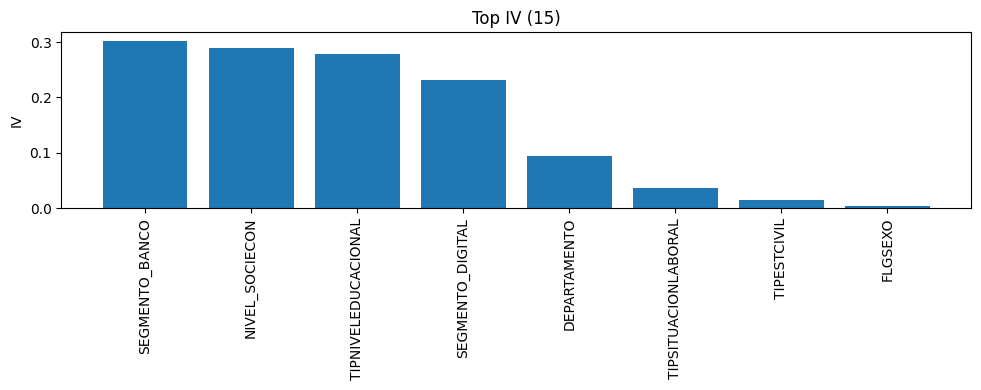

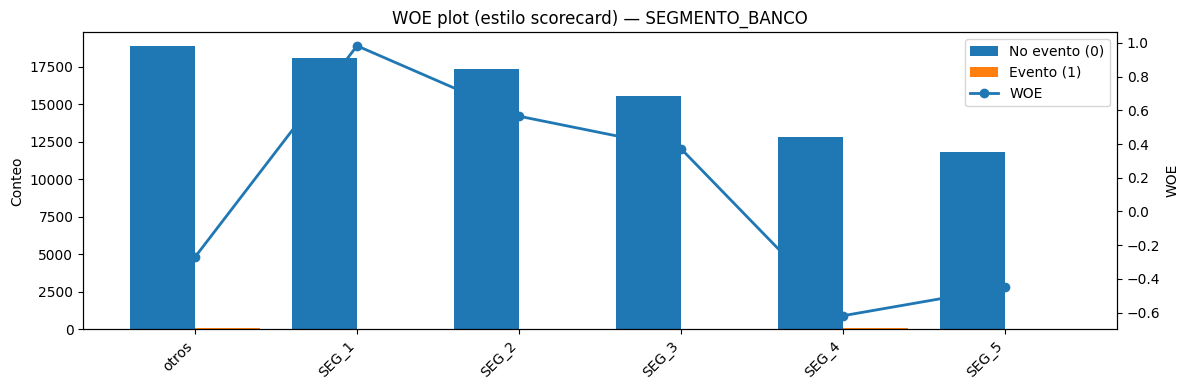

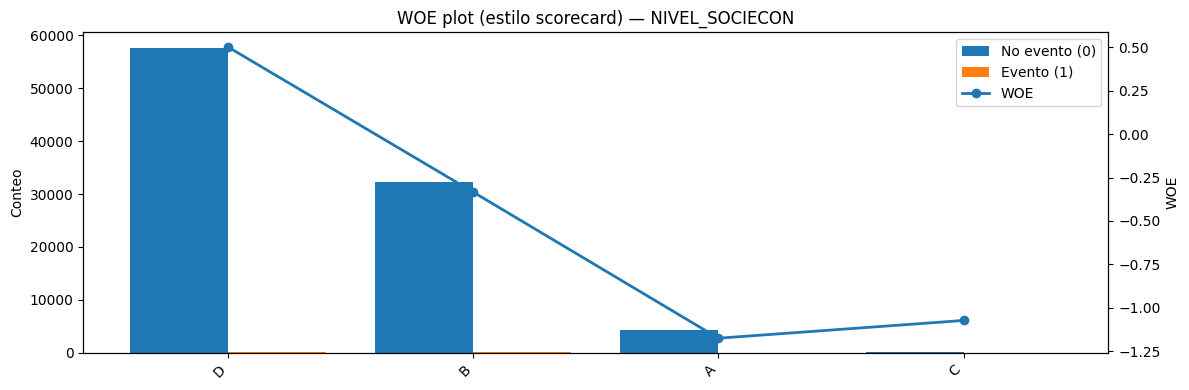

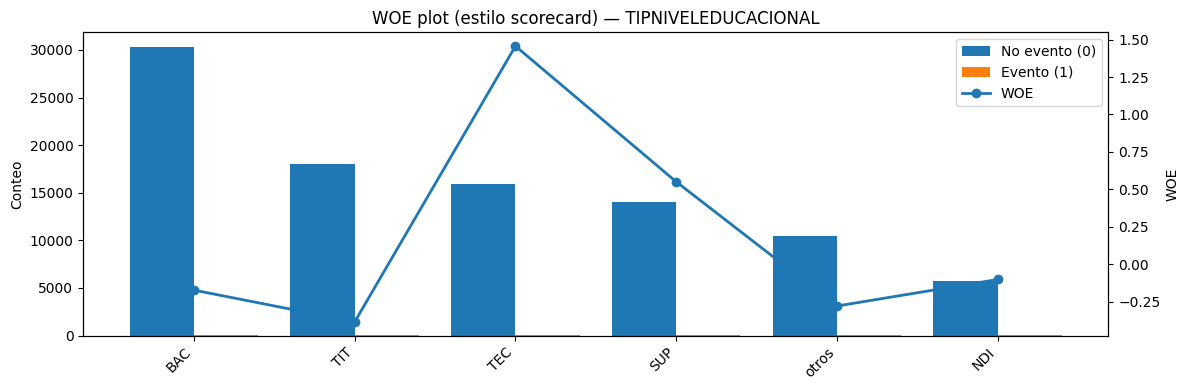

In [26]:
woe_maps = {}
iv_rows = []
details_map = {}

for c in cat_cols2:
    mapper, iv, detail = fit_woe_iv(train_df4, c, target=TARGET, eps=0.5)
    woe_maps[c] = mapper
    iv_rows.append((c, iv, len(mapper)))
    details_map[c] = detail

iv_df = pd.DataFrame(iv_rows, columns=["feature", "iv", "n_levels"]).sort_values("iv", ascending=False)
display(iv_df)

plt.figure(figsize=(10,4))
plt.bar(iv_df["feature"].head(15), iv_df["iv"].head(15))
plt.title("Top IV (15)")
plt.xticks(rotation=90)
plt.ylabel("IV")
plt.tight_layout()
plt.show()

# Plot para las TOP 3 variables por IV
top_feats = iv_df["feature"].head(3).tolist()
for f in top_feats:
    plot_woe_like_scorecardpy(details_map[f], f, top_n=15, order="freq")
    # opcional: también event-rate
    # plot_eventrate_like_scorecard(details_map[f], f, top_n=15)

### 11.1 Aplicar WOE a Train/Test/B

**Importante:** el mapa se aprende en **train** y se aplica a test/B; categorías nuevas → valor por defecto (0.0).

In [27]:
def apply_woe_series(s: pd.Series, mapper: dict, default_woe: float = 0.0) -> pd.Series:
    # Asegura string + nulos controlados (si ya usas TopK+otros, esto igual es seguro)
    s2 = s.fillna("otros").astype(str)
    return s2.map(mapper).fillna(default_woe).astype(float)


def woe_transform_dataset(df: pd.DataFrame, cat_cols: list, woe_maps: dict, default_woe: float = 0.0) -> pd.DataFrame:
    out = df.copy()

    for c in cat_cols:
        if c in out.columns and c in woe_maps:
            out[c] = apply_woe_series(out[c], woe_maps[c], default_woe=default_woe)
        elif c in out.columns and c not in woe_maps:
            # existe la columna, pero no hay mapa -> pon default
            out[c] = default_woe
        elif c not in out.columns and c in woe_maps:
            # hay mapa, pero no existe columna -> crea columna default (por seguridad)
            out[c] = default_woe
        else:
            # no existe ni columna ni mapa, no hacemos nada
            pass

    return out

train_df5 = woe_transform_dataset(train_df4, cat_cols2, woe_maps, default_woe=0.0)
test_df5  = woe_transform_dataset(test_df4,  cat_cols2, woe_maps, default_woe=0.0)
B5        = woe_transform_dataset(B4,        cat_cols2, woe_maps, default_woe=0.0)

X_train = train_df5[feature_cols2].copy()
y_train = train_df5[TARGET].astype(int).copy()

X_test  = test_df5[feature_cols2].copy()
y_test  = test_df5[TARGET].astype(int).copy()

X_B = B5[feature_cols2].copy()
y_B = B5[TARGET].astype(int).copy()

print("Tipos X_train:\n", X_train.dtypes.value_counts())

Tipos X_train:
 float64    11
int64       1
Name: count, dtype: int64


In [28]:
# 1) No NaNs en categóricas ya transformadas
print("NaNs en X_train:", X_train.isna().sum().sum())

# 2) Confirmar que cat_cols2 son numéricas ahora
non_numeric = [c for c in cat_cols2 if not pd.api.types.is_numeric_dtype(X_train[c])]
print("Categóricas que NO quedaron numéricas:", non_numeric)

# 3) Confirmar que no quedan strings en X_train
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
print("Columnas object en X_train:", obj_cols)

NaNs en X_train: 0
Categóricas que NO quedaron numéricas: []
Columnas object en X_train: []


## 12) Scaling (StandardScaler)

Regla: `fit` en train, `transform` en test/B.

In [29]:

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_B_s     = pd.DataFrame(scaler.transform(X_B), columns=X_B.columns, index=X_B.index)

## 13) Manejo del desbalance de clases

En muchos problemas de clasificación reales, las clases no aparecen con la misma frecuencia.  
A este fenómeno se le conoce como **desbalance de clases** (*class imbalance*).

Un dataset está desbalanceado cuando una clase aparece **mucho más frecuentemente que la otra**.

Ejemplo típico:

| Clase | Cantidad |
|------|------|
| No compra (0) | 443000 |
| Compra (1) | 1000 |

Esto significa que el modelo verá **muchos más ejemplos de la clase 0 que de la clase 1**.

---

## Problema del desbalance

Si entrenamos un modelo directamente sobre datos desbalanceados, el modelo puede aprender una regla trivial:

$$
\hat{y} = 0
$$

Es decir, **predecir siempre la clase mayoritaria**.

Esto puede producir una **accuracy muy alta**, pero un modelo inútil.

Ejemplo:

Si el $99.8\%$ de los clientes **no compra**, un modelo que siempre prediga **0** tendrá:

$$
Accuracy = 0.998
$$

pero el modelo **nunca detectará los eventos reales**.

---

## Métricas más adecuadas para datasets desbalanceados

Cuando existe desbalance, la métrica **accuracy pierde significado**.  
Por ello se utilizan métricas que capturan mejor la capacidad de detectar la clase minoritaria.

### Recall

$$
Recall = \frac{TP}{TP + FN}
$$

Mide qué proporción de los eventos reales logramos identificar.

---

### Precision

$$
Precision = \frac{TP}{TP + FP}
$$

Mide qué proporción de las predicciones positivas son correctas.

---

### F1 Score

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

Es la media armónica entre **precision** y **recall**.

---

### ROC-AUC

El **AUC (Area Under the Curve)** mide la capacidad del modelo para separar ambas clases.

$$
AUC \in [0,1]
$$

| AUC | Interpretación |
|----|----|
| 0.5 | Aleatorio |
| 0.6–0.7 | Bajo |
| 0.7–0.8 | Bueno |
| 0.8–0.9 | Muy bueno |
| >0.9 | Excelente |

---

# Estrategias para manejar datasets desbalanceados

Existen varias estrategias para tratar este problema.

---

## 1. Undersampling

El **undersampling** consiste en **reducir la cantidad de observaciones de la clase mayoritaria**.

Si el dataset original es:

| Clase | Observaciones |
|------|------|
| 0 | 443000 |
| 1 | 1000 |

Podemos crear un dataset balanceado reduciendo la clase mayoritaria:

| Clase | Observaciones |
|------|------|
| 0 | 1000 |
| 1 | 1000 |

Matemáticamente, si:

$$
N_0 >> N_1
$$

podemos reducir el dataset a:

$$
N_0' = N_1
$$

### Ventajas

- Reduce el desbalance rápidamente
- Entrenamiento más rápido

### Desventajas

- Se pierde información valiosa
- Puede eliminar patrones importantes

---

## 2. Oversampling

El **oversampling** consiste en **aumentar artificialmente la clase minoritaria**.

Si el dataset original es:

| Clase | Observaciones |
|------|------|
| 0 | 443000 |
| 1 | 1000 |

Podemos replicar la clase minoritaria:

| Clase | Observaciones |
|------|------|
| 0 | 443000 |
| 1 | 443000 |

Formalmente:

$$
N_1' = N_0
$$

### Ventajas

- No se pierde información de la clase mayoritaria

### Desventajas

- Puede producir **overfitting**
- El modelo ve repetidamente los mismos ejemplos

---

## 3. SMOTE (Synthetic Minority Oversampling Technique)

SMOTE es una técnica de **oversampling inteligente**.

En lugar de duplicar datos, SMOTE **genera nuevos ejemplos sintéticos** de la clase minoritaria.

El proceso es el siguiente:

1. Seleccionar una observación de la clase minoritaria
2. Encontrar sus $k$ vecinos más cercanos
3. Generar nuevos puntos interpolando entre ellos

La generación de una nueva observación se define como:

$$
x_{nuevo} = x_i + \lambda (x_{vecino} - x_i)
$$

donde:

- $x_i$ es una observación de la clase minoritaria  
- $x_{vecino}$ es uno de sus vecinos más cercanos  
- $\lambda \sim U(0,1)$ es un valor aleatorio

Esto crea **nuevos puntos dentro del espacio de características**, generando ejemplos plausibles.

---

## Ventajas de SMOTE

- No duplica exactamente los datos
- Reduce el riesgo de overfitting
- Mejora la representación de la clase minoritaria
- Muy utilizado en problemas de:
  - fraude
  - riesgo crediticio
  - marketing

---

## Consideración importante

SMOTE **solo debe aplicarse al dataset de entrenamiento**.

Nunca debe aplicarse sobre:

- test
- validación
- producción

Esto evita **data leakage**.



In [30]:

sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train_s, y_train)

print("Before:", y_train.value_counts().to_dict())
print("After :", pd.Series(y_train_bal).value_counts().to_dict())

Before: {0: 94459, 1: 213}
After : {0: 94459, 1: 94459}


## 14) Métricas + Curvas (ROC / PR) + KS + Lift + Gains

En problemas de **clasificación binaria**, especialmente cuando existe **desbalance de clases**, no basta con medir cuántas predicciones son correctas.  
Necesitamos métricas que evalúen **qué tan bien el modelo separa ambas clases** y **qué tan útil es para tomar decisiones de negocio**.

---

# 14.1 Matriz de confusión

Para un umbral de decisión \(t\), el modelo genera una predicción:

$$
\hat{y} =
\begin{cases}
1 & \text{si } p(x) \ge t \\
0 & \text{si } p(x) < t
\end{cases}
$$

Comparando la predicción con el valor real obtenemos la **matriz de confusión**.

|                | Predice 1 | Predice 0 |
|----------------|-----------|-----------|
| Real 1 | \(TP\) | \(FN\) |
| Real 0 | \(FP\) | \(TN\) |

donde:

- \(TP\): True Positives (evento detectado correctamente)  
- \(FN\): False Negatives (evento que el modelo no detectó)  
- \(FP\): False Positives (alarma falsa)  
- \(TN\): True Negatives (no evento correctamente identificado)

---

# 14.2 Métricas basadas en umbral

## Precision

$$
Precision = \frac{TP}{TP + FP}
$$

Indica qué proporción de las predicciones positivas son correctas.

---

## Recall (Sensibilidad)

$$
Recall = \frac{TP}{TP + FN}
$$

Mide qué proporción de los eventos reales fueron detectados.

---

## Specificity

$$
Specificity = \frac{TN}{TN + FP}
$$

Mide qué proporción de los no-eventos se clasificaron correctamente.

---

## F1 Score

El **F1 Score** combina precision y recall.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

Esta métrica es útil cuando queremos balancear **falsos positivos y falsos negativos**.

---

# 14.3 Curva ROC

La **ROC (Receiver Operating Characteristic)** evalúa el comportamiento del modelo para **todos los posibles umbrales**.

Se define mediante dos métricas:

## True Positive Rate

$$
TPR = \frac{TP}{TP + FN}
$$

## False Positive Rate

$$
FPR = \frac{FP}{FP + TN}
$$

La curva ROC grafica:

$$
TPR(t) \quad \text{vs} \quad FPR(t)
$$

para todos los valores del umbral \(t\).

---

# 14.4 AUC (Area Under the Curve)

El **AUC** mide el área bajo la curva ROC.

$$
AUC = \int_{0}^{1} TPR(FPR) \, d(FPR)
$$

También puede interpretarse como:

$$
AUC = P\left(s(x^+) > s(x^-)\right)
$$

Es decir, la probabilidad de que el modelo asigne un score mayor a un positivo que a un negativo.

Interpretación práctica:

| AUC | Interpretación |
|-----|---------------|
| 0.5 | Modelo aleatorio |
| 0.6–0.7 | Bajo |
| 0.7–0.8 | Bueno |
| 0.8–0.9 | Muy bueno |
| >0.9 | Excelente |

---

# 14.5 Curva Precision-Recall

En datasets **muy desbalanceados**, la curva ROC puede ser optimista.  
Por eso se utiliza la **curva Precision-Recall**.

La curva grafica:

$$
Precision(t) \quad \text{vs} \quad Recall(t)
$$

para diferentes valores del umbral.

---

# 14.6 Average Precision (PR-AUC)

La métrica equivalente al AUC en la curva PR es el **Average Precision**.

$$
AP = \sum_{n} (R_n - R_{n-1}) P_n
$$

donde:

- \(P_n\) es precision en el punto \(n\)
- \(R_n\) es recall en el punto \(n\)

La línea base para PR-AUC depende del desbalance:

$$
Baseline = \frac{N_{positivos}}{N}
$$

---

# 14.7 KS (Kolmogorov–Smirnov)

El **KS statistic** mide la máxima separación entre la distribución de scores de eventos y no-eventos.

Se define como:

$$
KS = \max_{t} |TPR(t) - FPR(t)|
$$

Interpretación:

| KS | Interpretación |
|----|---------------|
| < 0.2 | Débil |
| 0.2 – 0.4 | Aceptable |
| 0.4 – 0.6 | Bueno |
| > 0.6 | Excelente |

KS es ampliamente utilizado en **credit scoring**.

---

# 14.8 Lift

El **Lift** mide cuánto mejora el modelo respecto a una selección aleatoria.

Sea:

$$
ER_{base} = \frac{N_{eventos}}{N}
$$

y para un grupo \(k\):

$$
ER_k = \frac{Eventos_k}{N_k}
$$

Entonces:

$$
Lift_k = \frac{ER_k}{ER_{base}}
$$

Interpretación:

- \(Lift = 1\): igual que seleccionar al azar
- \(Lift > 1\): el modelo mejora la selección
- \(Lift = 3\): tres veces más eventos que el promedio

---

# 14.9 Gains

Los **Gains** miden la proporción acumulada de eventos capturados.

Si ordenamos los clientes por score:

$$
Gains(j) =
\frac{\sum_{k=1}^{j} Eventos_k}{N_{eventos}}
$$

y la población acumulada:

$$
Population(j) =
\frac{\sum_{k=1}^{j} N_k}{N}
$$

La curva Gains grafica:

$$
Gains(j) \quad \text{vs} \quad Population(j)
$$

Interpretación:

- Si el modelo es bueno, el **top 10% de clientes** capturará mucho más que el **10% de los eventos**.

---

# 14.10 Interpretación para negocio

Estas métricas permiten conectar el modelo con decisiones operativas.

Ejemplo:

- Contactar solo el **top 20% de clientes**
- Si el modelo captura **60% de los eventos en ese grupo**, el modelo tiene un **Gains alto**

Esto permite optimizar campañas de:

- marketing
- detección de fraude
- gestión de riesgo crediticio

In [31]:

def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(np.abs(tpr - fpr)))

def lift_gains_table(y_true, y_score, n_bins=10):
    df_ = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score", ascending=False).reset_index(drop=True)
    df_["bucket"] = pd.qcut(df_.index + 1, q=n_bins, labels=False) + 1  # 1..n_bins

    total_events = df_["y"].sum()
    total = len(df_)

    agg = df_.groupby("bucket").agg(
        n=("y","size"),
        events=("y","sum"),
        avg_score=("score","mean")
    ).reset_index()

    agg["event_rate"] = agg["events"] / agg["n"]
    agg["cum_events"] = agg["events"].cumsum()
    agg["cum_event_rate"] = agg["cum_events"] / (total_events if total_events > 0 else 1)
    agg["cum_pop"] = agg["n"].cumsum() / total

    base_rate = total_events / total if total > 0 else 0
    agg["lift"] = agg["event_rate"] / (base_rate if base_rate > 0 else 1e-12)
    return agg

def evaluate_model(name, model, X_te, y_te):
    prob = model.predict_proba(X_te)[:, 1]
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_te, prob),
        "pr_auc": average_precision_score(y_te, prob),
        "ks": ks_statistic(y_te, prob),
        "prob": prob
    }

def plot_roc_pr(y_true, prob, title_prefix=""):
    fpr, tpr, _ = roc_curve(y_true, prob)
    prec, rec, _ = precision_recall_curve(y_true, prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title(f"{title_prefix} ROC Curve")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.show()

    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.show()

## 15) Modelos + Optimización de Hiperparámetros (Hyperparameter Tuning)

Una vez que los datos han sido preparados y balanceados (por ejemplo mediante **SMOTE**), el siguiente paso es entrenar modelos y optimizar sus **hiperparámetros**.

Un **hiperparámetro** es un parámetro del modelo que **no se aprende directamente de los datos**, sino que debe ser definido antes del entrenamiento.

Ejemplos:

| Modelo | Hiperparámetro |
|------|------|
| Logistic Regression | regularización \(C\) |
| Random Forest | número de árboles \(n\_estimators\) |
| Gradient Boosting | learning rate |
| SVM | parámetro \(C\) y kernel |

Formalmente, si el modelo es:

$$
\hat{y} = f(x \mid \theta, \lambda)
$$

donde:

- \( \theta \) = parámetros aprendidos del modelo  
- \( \lambda \) = hiperparámetros definidos antes del entrenamiento

El objetivo del tuning es encontrar:

$$
\lambda^* = \arg\min_{\lambda} L(f(x \mid \theta, \lambda))
$$

donde \(L\) es la función de pérdida o métrica de evaluación.

---

# 15.1 Validación cruzada (Cross Validation)

Para evaluar correctamente diferentes configuraciones de hiperparámetros, se utiliza **cross-validation**.

En **k-fold cross-validation**, el dataset se divide en \(k\) subconjuntos.

En cada iteración:

1. Se entrena el modelo con \(k-1\) folds
2. Se valida en el fold restante

La métrica final es:

$$
CV = \frac{1}{k} \sum_{i=1}^{k} Score_i
$$

Esto permite estimar el desempeño del modelo en datos no vistos.

---

# 15.2 Grid Search

**Grid Search** es uno de los métodos más utilizados para optimizar hiperparámetros.

Consiste en evaluar **todas las combinaciones posibles** de un conjunto de hiperparámetros.

Ejemplo:

| C | penalty |
|---|---|
|0.01|l2|
|0.1|l2|
|1|l2|
|10|l2|

El algoritmo evalúa todas las combinaciones y selecciona la mejor según una métrica.

Formalmente:

$$
\lambda^* = \arg\max_{\lambda \in \Lambda} Score(\lambda)
$$

donde \( \Lambda \) es el conjunto de combinaciones.

Ventajas:

- simple de implementar
- exhaustivo

Desventajas:

- costo computacional alto
- crece exponencialmente con el número de parámetros

---

# 15.3 Random Search

Una alternativa más eficiente es **Random Search**.

En lugar de evaluar todas las combinaciones, se **muestran aleatoriamente configuraciones de hiperparámetros**.

$$
\lambda_i \sim P(\Lambda)
$$

Esto suele encontrar buenas soluciones con menos evaluaciones.

Ventajas:

- más eficiente en espacios grandes
- mejor exploración de hiperparámetros

---

# 15.4 Bayesian Optimization

Métodos más avanzados utilizan **optimización bayesiana**, donde el algoritmo aprende qué hiperparámetros probar.

La idea es modelar la función objetivo:

$$
f(\lambda) = Score(\lambda)
$$

y construir un modelo probabilístico:

$$
p(f(\lambda))
$$

Luego seleccionar los hiperparámetros que maximicen una función de adquisición.

Librerías comunes:

- Optuna
- Hyperopt
- Bayesian Optimization

---

# 15.5 Modelos utilizados en este proyecto

En este proyecto utilizaremos dos modelos principales:

---

## Logistic Regression

La regresión logística modela la probabilidad de evento como:

$$
P(y=1|x) =
\frac{1}{1 + e^{-(\beta_0 + \beta^T x)}}
$$

donde:

- \(x\) son las variables
- \(\beta\) son los coeficientes

El principal hiperparámetro es la regularización:

$$
\min_{\beta}
\left[
L(\beta) + \lambda ||\beta||_2^2
\right]
$$

donde \( \lambda \) controla la penalización.

---

## Random Forest

Random Forest es un método de **ensemble basado en árboles de decisión**.

El modelo construye múltiples árboles:

$$
\hat{f}(x) =
\frac{1}{B} \sum_{b=1}^{B} T_b(x)
$$

donde:

- \(T_b\) es el árbol \(b\)
- \(B\) es el número total de árboles

Cada árbol se entrena con:

- **bootstrap sampling**
- selección aleatoria de features

Esto reduce **varianza** y mejora generalización.

Hiperparámetros importantes:

| Parámetro | Descripción |
|------|------|
| n_estimators | número de árboles |
| max_depth | profundidad máxima |
| min_samples_leaf | tamaño mínimo de hoja |
| max_features | número de features por split |

---

# 15.6 Manejo del desbalance en modelos

Incluso después de aplicar **SMOTE**, algunos modelos pueden seguir siendo sensibles al desbalance.

Por eso se pueden utilizar **class weights**:

$$
Loss =
\sum_{i=1}^{N} w_i L(y_i, \hat{y}_i)
$$

donde:

$$
w_i =
\begin{cases}
w_{pos} & \text{si } y_i = 1 \\
w_{neg} & \text{si } y_i = 0
\end{cases}
$$

Esto penaliza más los errores en la clase minoritaria.

---

# 15.7 Estrategia utilizada en este proyecto

En este notebook utilizaremos:

- **SMOTE** para balancear el dataset de entrenamiento
- **GridSearchCV** para encontrar los mejores hiperparámetros
- **cross-validation** para evaluar cada configuración

Los modelos evaluados serán:

1. Logistic Regression
2. Random Forest

Finalmente se compararán usando:

- ROC-AUC
- PR-AUC
- KS
- Lift / Gains

In [32]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic (entrena en datos balanceados por SMOTE)
logit = LogisticRegression(max_iter=2000, solver="lbfgs")

param_grid_logit = {
    "C": [0.01, 0.1, 1.0, 5.0, 10.0],
    "class_weight": [None, "balanced"]
}

grid_logit = GridSearchCV(
    estimator=logit,
    param_grid=param_grid_logit,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_logit.fit(X_train_bal, y_train_bal)
best_logit = grid_logit.best_estimator_
print("Best Logistic params:", grid_logit.best_params_)

# RandomForest (entrena en train original con class_weight)
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_grid_rf = {
    "n_estimators": [300, 600],
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [1, 5, 20],
    "class_weight": [None, "balanced_subsample"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train_s, y_train)
best_rf = grid_rf.best_estimator_
print("Best RF params:", grid_rf.best_params_)

Best Logistic params: {'C': 0.01, 'class_weight': 'balanced'}


/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

Best RF params: {'class_weight': 'balanced_subsample', 'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 300}


## 16) Evaluación en Test (dentro de A)

,model,roc_auc,pr_auc,ks
1,RandomForest,0.737774,0.012827,0.401808
0,Logistic (SMOTE),0.732757,0.007179,0.352046


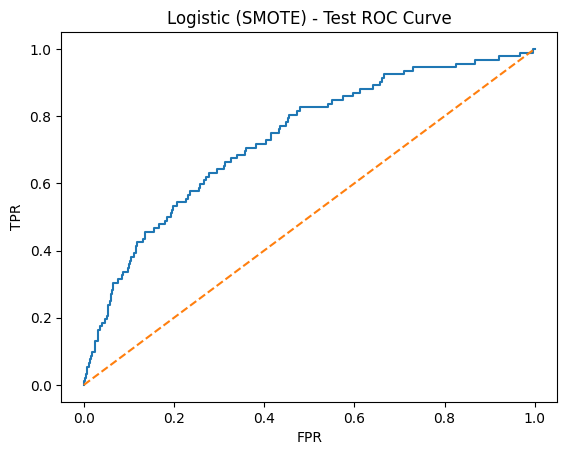

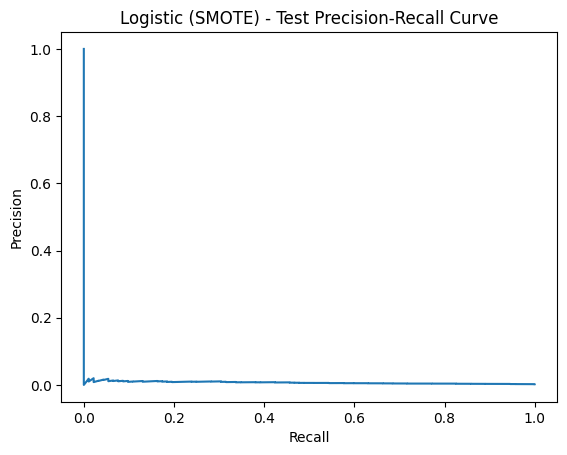

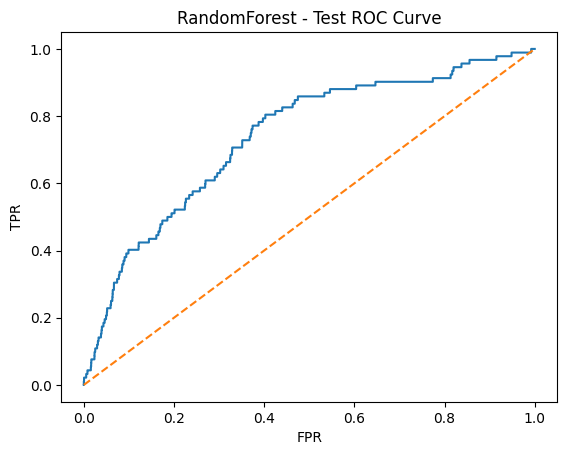

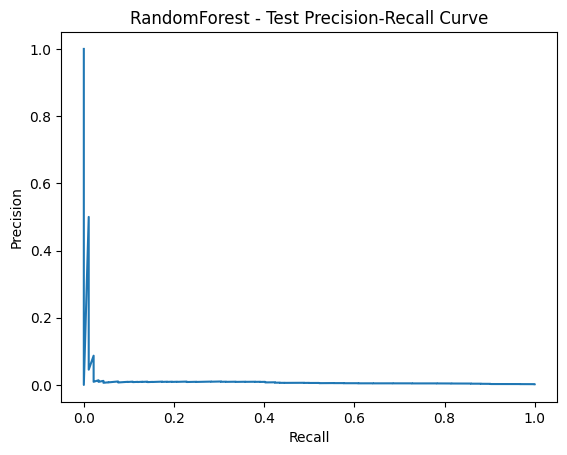

,bucket,n,events,avg_score,event_rate,cum_events,cum_event_rate,cum_pop,lift
0,1,4058,32,0.757901,0.007886,32,0.347826,0.100012,3.477832
1,2,4057,17,0.671038,0.004190,49,0.532609,0.200000,1.848054
2,3,4058,10,0.602199,0.002464,59,0.641304,0.300012,1.086823
3,4,4057,7,0.530625,0.001725,66,0.717391,0.400000,0.760963
4,5,4058,10,0.448808,0.002464,76,0.826087,0.500012,1.086823
5,6,4057,4,0.356192,0.000986,80,0.869565,0.600000,0.434836
6,7,4057,5,0.253782,0.001232,85,0.923913,0.699988,0.543545
7,8,4058,2,0.164859,0.000493,87,0.945652,0.800000,0.217365
8,9,4057,2,0.095116,0.000493,89,0.967391,0.899988,0.217418
9,10,4058,3,0.031820,0.000739,92,1.000000,1.000000,0.326047


,bucket,n,events,avg_score,event_rate,cum_events,cum_event_rate,cum_pop,lift
0,1,4058,37,0.670420,0.009118,37,0.402174,0.100012,4.021244
1,2,4057,10,0.578815,0.002465,47,0.510870,0.200000,1.087090
2,3,4058,11,0.494383,0.002711,58,0.630435,0.300012,1.195505
3,4,4057,15,0.400380,0.003697,73,0.793478,0.400000,1.630636
4,5,4058,6,0.339560,0.001479,79,0.858696,0.500012,0.652094
5,6,4057,2,0.285123,0.000493,81,0.880435,0.600000,0.217418
6,7,4057,2,0.225223,0.000493,83,0.902174,0.699988,0.217418
7,8,4058,1,0.175913,0.000246,84,0.913043,0.800000,0.108682
8,9,4057,5,0.133111,0.001232,89,0.967391,0.899988,0.543545
9,10,4058,3,0.077428,0.000739,92,1.000000,1.000000,0.326047


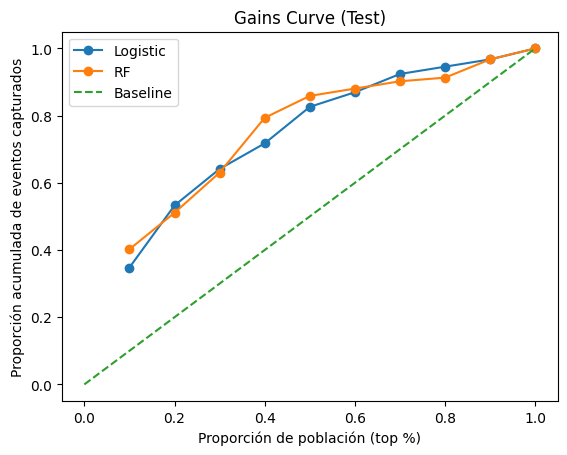

In [33]:

res_logit = evaluate_model("Logistic (SMOTE)", best_logit, X_test_s, y_test)
res_rf    = evaluate_model("RandomForest", best_rf, X_test_s, y_test)

summary = pd.DataFrame([
    {k:v for k,v in res_logit.items() if k!="prob"},
    {k:v for k,v in res_rf.items() if k!="prob"},
]).sort_values("roc_auc", ascending=False)

display(summary)

plot_roc_pr(y_test, res_logit["prob"], title_prefix="Logistic (SMOTE) - Test")
plot_roc_pr(y_test, res_rf["prob"], title_prefix="RandomForest - Test")

lg_logit = lift_gains_table(y_test, res_logit["prob"], n_bins=10)
lg_rf    = lift_gains_table(y_test, res_rf["prob"], n_bins=10)

display(lg_logit)
display(lg_rf)

plt.figure()
plt.plot(lg_logit["cum_pop"], lg_logit["cum_event_rate"], marker="o", label="Logistic")
plt.plot(lg_rf["cum_pop"], lg_rf["cum_event_rate"], marker="o", label="RF")
plt.plot([0,1],[0,1], linestyle="--", label="Baseline")
plt.title("Gains Curve (Test)")
plt.xlabel("Proporción de población (top %)")
plt.ylabel("Proporción acumulada de eventos capturados")
plt.legend()
plt.show()

### Interpretación de la Gains Curve

La **Gains Curve** muestra qué proporción de los eventos reales podemos capturar si priorizamos a los clientes con mayor score del modelo.  
Este tipo de gráfico es muy utilizado en problemas de **marketing, churn, fraude o riesgo**, ya que permite evaluar el valor operativo de un modelo predictivo.

En el eje horizontal se observa la **proporción de población seleccionada** (top %).  
Esto significa que los clientes han sido ordenados de mayor a menor según la probabilidad estimada por el modelo. Por ejemplo:

- 0.1 representa el **10% de clientes con mayor probabilidad de evento**
- 0.2 representa el **20%**
- 0.5 representa el **50% de la población con mayor score**

En el eje vertical se muestra la **proporción acumulada de eventos capturados**.  
Esto indica qué porcentaje de todos los eventos reales se encuentran dentro del grupo seleccionado.

La línea verde punteada representa el **baseline o comportamiento aleatorio**.  
Si seleccionáramos clientes al azar, capturaríamos eventos de manera proporcional a la población seleccionada. Matemáticamente:

$$
Gains_{aleatorio}(p) = p
$$

donde \(p\) es la proporción de población seleccionada.

Por esta razón, cualquier modelo útil debe situarse **por encima de esta línea**, ya que significa que el modelo logra concentrar los eventos en los primeros percentiles.

Observando las curvas del gráfico, tanto **Logistic Regression** como **Random Forest** se encuentran claramente por encima de la línea base. Esto indica que ambos modelos poseen **capacidad predictiva real** y son capaces de priorizar correctamente los clientes con mayor probabilidad de evento.

En el **top 10% de la población**, el modelo logístico captura aproximadamente **35% de los eventos**, mientras que Random Forest captura cerca de **40%**. Esto significa que si una empresa contacta únicamente al 10% de clientes con mayor score, podría identificar alrededor del 35–40% de las ventas potenciales.

En el **top 20% de clientes**, ambos modelos capturan aproximadamente **50% de los eventos**, lo cual indica una fuerte concentración de eventos en los primeros percentiles.

Cuando se alcanza alrededor del **40% de la población**, el modelo Random Forest captura aproximadamente **80% de los eventos**, mientras que la regresión logística captura cerca de **72%**, mostrando una ligera ventaja del modelo de Random Forest en ese rango.

Este comportamiento también puede interpretarse mediante el concepto de **Lift**, que mide cuánto mejora el modelo respecto a una selección aleatoria. El lift se define como:

$$
Lift(p) = \frac{Gains(p)}{p}
$$

Por ejemplo, si en el top 10% capturamos el 40% de los eventos:

$$
Lift = \frac{0.40}{0.10} = 4
$$

Esto significa que el modelo identifica **cuatro veces más eventos que una selección aleatoria**.

En términos de negocio, este gráfico permite tomar decisiones operativas. Por ejemplo, si una empresa solo puede contactar al **20% de su base de clientes**, el modelo permitiría capturar aproximadamente **la mitad de todos los eventos**, mejorando significativamente la eficiencia de una campaña.

En conclusión, ambos modelos presentan un buen desempeño al concentrar eventos en los primeros percentiles de la población. El modelo de **Random Forest** muestra una ligera ventaja en algunos tramos, particularmente en la captura temprana de eventos, lo cual puede resultar beneficioso cuando el objetivo es priorizar a los clientes con mayor probabilidad de respuesta.

## 17) Threshold tuning + matriz de confusión

In [34]:

def threshold_report(y_true, prob, thresholds=(0.05, 0.10, 0.15, 0.20, 0.30, 0.50)):
    rows = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "tp": int(((pred==1) & (y_true==1)).sum()),
            "fp": int(((pred==1) & (y_true==0)).sum()),
            "fn": int(((pred==0) & (y_true==1)).sum()),
            "tn": int(((pred==0) & (y_true==0)).sum()),
        })
    return pd.DataFrame(rows)

thr_logit = threshold_report(y_test.values, res_logit["prob"])
thr_rf    = threshold_report(y_test.values, res_rf["prob"])

display(thr_logit)
display(thr_rf)

,threshold,precision,recall,f1,tp,fp,fn,tn
0,0.05,0.002384,0.967391,0.004757,89,37241,3,3242
1,0.10,0.002575,0.956522,0.005136,88,34087,4,6396
2,0.15,0.002786,0.945652,0.005556,87,31137,5,9346
3,0.20,0.002969,0.923913,0.005919,85,28543,7,11940
4,0.30,0.003258,0.869565,0.006491,80,24476,12,16007
5,0.50,0.004170,0.717391,0.008292,66,15760,26,24723


,threshold,precision,recall,f1,tp,fp,fn,tn
0,0.05,0.002276,0.989130,0.004542,91,39884,1,599
1,0.10,0.002409,0.978261,0.004805,90,37276,2,3207
2,0.15,0.002557,0.913043,0.005099,84,32769,8,7714
3,0.20,0.002935,0.902174,0.005850,83,28200,9,12283
4,0.30,0.003697,0.858696,0.007362,79,21291,13,19192
5,0.50,0.005302,0.576087,0.010508,53,9943,39,30540


## 18) Interpretabilidad (Logistic) — coeficientes

In [35]:

coef = pd.DataFrame({
    "feature": X_train_s.columns,
    "coef": best_logit.coef_[0]
}).sort_values("coef", ascending=False)

display(coef.head(20))
display(coef.tail(20))

,feature,coef
11,LOG_INGRESO,0.633467
9,SEGMENTO_BANCO,0.036421
10,INGRESO_POR_EDAD,0.033477
1,TIPESTCIVIL,-0.065988
7,NIVEL_SOCIECON,-0.070820
0,FLGSEXO,-0.105757
6,INGRESO_ESTIMADO,-0.166347
3,TIPSITUACIONLABORAL,-0.245276
4,EDAD,-0.327275
5,DEPARTAMENTO,-0.372956


,feature,coef
11,LOG_INGRESO,0.633467
9,SEGMENTO_BANCO,0.036421
10,INGRESO_POR_EDAD,0.033477
1,TIPESTCIVIL,-0.065988
7,NIVEL_SOCIECON,-0.070820
0,FLGSEXO,-0.105757
6,INGRESO_ESTIMADO,-0.166347
3,TIPSITUACIONLABORAL,-0.245276
4,EDAD,-0.327275
5,DEPARTAMENTO,-0.372956


## 19) Validación final en B (producción simulada)

In [36]:

best_name = summary.iloc[0]["model"]
print("Modelo elegido (según Test):", best_name)

chosen = best_logit if best_name.startswith("Logistic") else best_rf

prob_B = chosen.predict_proba(X_B_s)[:, 1]

metrics_B = {
    "roc_auc": roc_auc_score(y_B, prob_B),
    "pr_auc": average_precision_score(y_B, prob_B),
    "ks": ks_statistic(y_B, prob_B),
    "event_rate_B": float(y_B.mean())
}
metrics_B

Modelo elegido (según Test): RandomForest


{'roc_auc': 0.7555328994171462,
 'pr_auc': 0.007286273310572234,
 'ks': 0.414054016948941,
 'event_rate_B': 0.00224772270199929}

## 20) Gains/Lift en B

,bucket,n,events,avg_score,event_rate,cum_events,cum_event_rate,cum_pop,lift
0,1,3382,29,0.671511,0.008575,29,0.381579,0.100024,3.814887
1,2,3381,15,0.578504,0.004437,44,0.578947,0.200018,1.973801
2,3,3381,8,0.492183,0.002366,52,0.684211,0.300012,1.052694
3,4,3381,8,0.400834,0.002366,60,0.789474,0.400006,1.052694
4,5,3381,3,0.340353,0.000887,63,0.828947,0.500000,0.394760
5,6,3381,7,0.285788,0.002070,70,0.921053,0.599994,0.921107
6,7,3381,0,0.225728,0.000000,70,0.921053,0.699988,0.000000
7,8,3381,2,0.175684,0.000592,72,0.947368,0.799982,0.263173
8,9,3381,3,0.131684,0.000887,75,0.986842,0.899976,0.394760
9,10,3382,1,0.076134,0.000296,76,1.000000,1.000000,0.131548


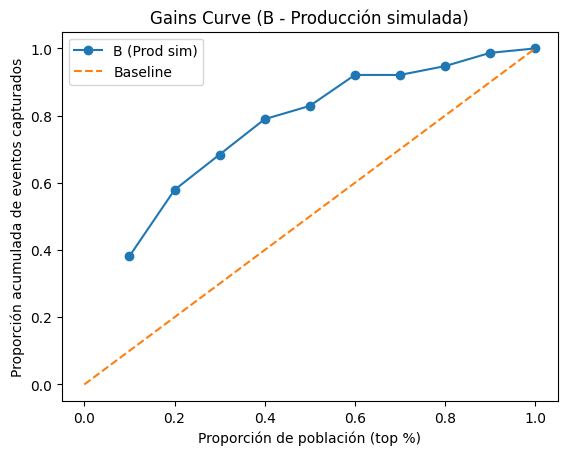

In [38]:

lg_B = lift_gains_table(y_B, prob_B, n_bins=10)
display(lg_B)

plt.figure()
plt.plot(lg_B["cum_pop"], lg_B["cum_event_rate"], marker="o", label="B (Prod sim)")
plt.plot([0,1],[0,1], linestyle="--", label="Baseline")
plt.title("Gains Curve (B - Producción simulada)")
plt.xlabel("Proporción de población (top %)")
plt.ylabel("Proporción acumulada de eventos capturados")
plt.legend()
plt.show()

## 21) Guardar artefactos para producción

**Por qué:** para replicar exactamente el pipeline en producción.

In [39]:

import json

artifacts = {
    "topk_map": {k: sorted(list(v)) for k,v in topk_map.items()},
    "num_medians": num_medians,
    "woe_maps": woe_maps,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "model_type": type(chosen).__name__
}

art_path = "artefactos_reto/Clase10_artifacts.json"
with open(art_path, "w", encoding="utf-8") as f:
    json.dump(artifacts, f, ensure_ascii=False, indent=2)

print("Artifacts guardados en:", art_path)

Artifacts guardados en: artefactos_reto/Clase10_artifacts.json


# Cierre

Pipeline completo estilo industria (banca): A/B, PSI, TopK, WOE/IV, SMOTE, tuning, KS/Lift/Gains, validación en B.
